# <center> Big Data For Finance Project: Bankruptcy Prediction Model

> - __Ahmed Abdelazeem__ (m20210433)
> - __Omar Jarir__ (m20201378)  
> - __Chung-Ting Huang__ (m20210437) 
> - __Pedro Moura Gomes__ (m20200322)

***

The goal of this project is to build following four Classification models to accurately classify "Response" variable:

- Logistic Regression.
- Random Forest.
- Gradient Boosted Tree.
- Artificial Neural Network.

***

In [1]:
# Great this is working

import findspark
findspark.init('C:/spark') 
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif, VarianceThreshold 
from sklearn.metrics import auc
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import sklearn.metrics as metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn import metrics

In [3]:
from pyspark.sql.functions import isnan, when, count, col
from pyspark.ml.classification import (LogisticRegression, RandomForestClassifier, GBTClassifier, 
                                       MultilayerPerceptronClassifier, DecisionTreeClassifier) 
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, StandardScaler
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans 
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

In [4]:
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import VectorAssembler, VectorIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

#import mlflow
#import mlflow.spark
from pyspark.mllib.evaluation import BinaryClassificationMetrics
from pyspark.ml.stat import Correlation

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
import time
t1 = time.perf_counter()

In [7]:
SEED = 2022

### Helper functions:

In [8]:
def MutualInfoScores(X, y):    
    mi = pd.Series(mutual_info_classif(X, y))
    mi /= mi.max()
    mi.index = X.columns
    mi.sort_values(ascending=False).plot.bar(figsize=(20, 6))
    plt.title("Feature univariate score")
    plt.ylabel('Mutual Information')
    plt.show();
    return mi

In [9]:
def FTestScores(X, y):
    f_scores = pd.Series(-np.log10(f_classif(X, y)[1]))
    f_scores /= f_scores.max()
    f_scores.index = X.columns
    f_scores = f_scores.sort_values(ascending=False)
    f_scores.plot.bar(figsize=(20,6))
    plt.title("Feature univariate score")
    plt.ylabel(r"Univariate score ($-Log(p_{value})$)")
    plt.show();
    return f_scores

In [10]:
def remove_correlated(X):
    corr = np.abs(X.corr())
    i = 1
    for (index, row) in corr.iterrows():
        for col in corr.columns[i:]:
            if row[col] > 0.9:
                print(f"{index} vs. {col} are highly correlated {row[col]}")
        i += 1
        # Select upper triangle of correlation matrix
    corr_matrix = corr.where(np.triu(np.ones(corr.shape), k=1).astype(np.bool))
    # Find features with correlation greater than 0.9
    correlated_cols = [c for c in corr_matrix.columns if any(corr_matrix[c] > 0.9)]
    # Drop correlated columns
    return correlated_cols

In [11]:
# Function to plot confusion matrix - Adapted from https://github.com/DTrimarchi10/confusion_matrix/blob/master/cf_matrix.py
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf:            confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    normalize:     If True, show the proportions for each category. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html
                   
    title:         Title for the heatmap. Default is None.
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    ax = sns.heatmap(cf,annot=box_labels, fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('True label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)
    
    if title:
        plt.title(title)

In [12]:
def performanceMetricsDF(metricsObj, yTrain, yPredTrain, yTest, yPredTest):
    measures_list = ['ACCURACY','PRECISION', 'RECALL','F1 SCORE','AUC']
    train_results = [metricsObj.accuracy_score(yTrain, yPredTrain),
                metricsObj.precision_score(yTrain, yPredTrain, average='macro'),
                metricsObj.recall_score(yTrain, yPredTrain, average='macro'),
                metricsObj.f1_score(yTrain, yPredTrain, average='macro'),
                metricsObj.roc_auc_score(yTrain, yPredTrain, average='macro'),    
                ]
    test_results = [metricsObj.accuracy_score(yTest, yPredTest),
               metricsObj.precision_score(yTest, yPredTest, average='macro'),
               metricsObj.recall_score(yTest, yPredTest, average='macro'),
               metricsObj.f1_score(yTest, yPredTest, average='macro'),
               metricsObj.roc_auc_score(yTest, yPredTest, average='macro'), 
               ]
    resultsDF = pd.DataFrame({'Train': train_results, 'Test':test_results}, index=measures_list)
    return resultsDF

In [13]:
def Metrics(predDF, eps= 0.0001):

    tp = predDF.filter("prediction == 1.0 AND Response == 1").count()
    fp = predDF.filter("prediction == 1.0 AND Response == 0").count()
    tn = predDF.filter("prediction == 0.0 AND Response == 0").count()
    fn = predDF.filter("prediction == 0.0 AND Response == 1").count()

    pres = tp/(tp+fp+eps) 
    rec = tp/(tp+fn+eps)

    print("Accuracy: {:.4}".format((tp+tn)/(tp+fp+tn+fn)))
    print("Precision: {:.4}".format(pres))
    print("Recall: {:.4}".format(rec))
    print("F1 score: {:.4}".format((2*pres*rec)/(pres+rec+eps)))
    print("Specificity: {:.4}".format((tn)/(tn+fp+eps)))
    print("Sensitivity: {:.4}".format((tp)/(tp+fn+eps)))

In [14]:
def Pipeline_model(stages, cv, train_data, test_data):
    """
    
    """
    p = Pipeline(stages=stages + [cv]) 
    pipeline_model = p.fit(train_data)
    predDF = pipeline_model.transform(test_data)
    y_test = predDF.select(["Response"]).collect()
    y_pred_test = predDF.select(["prediction"]).collect()
    firstelement = udf(lambda v: float(v[1]), FloatType())
    y_pred_test_proba = predDF.select(firstelement('probability')).collect()
    print(classification_report(y_test, y_pred_test))
    return pipeline_model, predDF, y_test, y_pred_test, y_pred_test_proba

In [15]:
def auc_plot(y_test, y_pred_test_proba):
    fpr, tpr, _ = roc_curve(y_test, y_pred_test_proba)
    auc_keras = auc(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.plot(fpr, tpr, label='AUC (area = {:.3f})'.format(auc_keras), color="g")
    plt.grid(axis='both', linestyle='--', color="#add8e6")
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC curve')
    plt.legend(loc='best')
    plt.show();

***

### Loading the data:

In [16]:
# Load and parse the data file, converting it to a DataFrame.

# data = spark.read.csv("train.csv", header="true", sep=",", inferSchema="true")
data = pd.read_csv("train.csv").sample(frac=0.01, random_state =SEED)
data = spark.createDataFrame(data=data)

In [17]:
data.printSchema()

root
 |-- id: long (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Driving_License: long (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: long (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: long (nullable = true)
 |-- Response: long (nullable = true)



In [18]:
data.toPandas().tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
3806,377036,Male,50,1,28.0,0,1-2 Year,Yes,57222.0,122.0,130,1
3807,356692,Male,44,1,22.0,0,1-2 Year,No,31059.0,26.0,114,0
3808,89007,Female,26,1,37.0,0,< 1 Year,Yes,18764.0,152.0,152,0
3809,63376,Female,24,1,50.0,1,< 1 Year,No,2630.0,152.0,284,0
3810,284379,Male,47,1,2.0,1,1-2 Year,No,2630.0,124.0,216,0


In [19]:
data.show(5, truncate=False)

+------+------+---+---------------+-----------+------------------+-----------+--------------+--------------+--------------------+-------+--------+
|id    |Gender|Age|Driving_License|Region_Code|Previously_Insured|Vehicle_Age|Vehicle_Damage|Annual_Premium|Policy_Sales_Channel|Vintage|Response|
+------+------+---+---------------+-----------+------------------+-----------+--------------+--------------+--------------------+-------+--------+
|122810|Male  |52 |1              |30.0       |0                 |1-2 Year   |Yes           |2630.0        |156.0               |180    |0       |
|226069|Male  |40 |1              |28.0       |0                 |1-2 Year   |Yes           |29651.0       |124.0               |47     |0       |
|152073|Male  |38 |1              |41.0       |0                 |1-2 Year   |Yes           |33874.0       |26.0                |285    |0       |
|340809|Female|21 |1              |11.0       |0                 |< 1 Year   |Yes           |2630.0        |160.0     

In [20]:
data.count()

3811

In [21]:
# Checking if the data frame contains duplicates
data.distinct().count()

3811

In [22]:
data.select([count(when(isnan(c), c)).alias(c) for c in data.columns]).toPandas()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
# Dropping the "id" columns.

data = data.drop(col("id"))

***

## Data exploration:

In [24]:
data.describe().toPandas().T

,0,1,2,3,4
summary,count,mean,stddev,min,max
Gender,3811,None,None,Female,Male
Age,3811,38.54683810023616,15.372081498810267,20,81
Driving_License,3811,0.9986880083967462,0.03620240577983318,0,1
Region_Code,3811,26.296510102335343,13.181599992739832,0.0,52.0
Previously_Insured,3811,0.4612962477040147,0.49856518448984327,0,1
Vehicle_Age,3811,None,None,1-2 Year,> 2 Years
Vehicle_Damage,3811,None,None,No,Yes
Annual_Premium,3811,30551.957229073734,17258.659825100483,2630.0,318706.0
Policy_Sales_Channel,3811,111.85174494883233,54.59658117582285,1.0,163.0


In [25]:
data.createOrReplaceTempView("dataTable")

In [26]:
data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Driving_License: long (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: long (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: long (nullable = true)
 |-- Response: long (nullable = true)



In [27]:
# As we can see from the query bellow the number of zero response is way higher than 1.

spark.sql("""SELECT count(*) as _count, Response
          From dataTable
          Group by Response
          ORDER BY _count""").show()

+------+--------+
|_count|Response|
+------+--------+
|   484|       1|
|  3327|       0|
+------+--------+



In [28]:
# As we can see from the query bellow the number of males in the dataset is higher than the number of females.

spark.sql("""SELECT gender, count(gender) as gender_count
          From dataTable
          Group by gender
          ORDER BY gender_count""").show()

+------+------------+
|gender|gender_count|
+------+------------+
|Female|        1744|
|  Male|        2067|
+------+------------+



In [29]:
data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Driving_License: long (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: long (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: long (nullable = true)
 |-- Response: long (nullable = true)



In [30]:
# We can notice few age difference between the responders.

spark.sql("""SELECT mean(Age) as mean_age, Response
          From dataTable
          Group by Response
          ORDER BY mean_age""").show()

+-----------------+--------+
|         mean_age|Response|
+-----------------+--------+
|37.93718064322212|       0|
|42.73760330578512|       1|
+-----------------+--------+



In [31]:
# We can see that almost half of the vehicles had danmage.

spark.sql("""SELECT count(Vehicle_Damage) as count_vehicle_damage, Vehicle_damage
          From dataTable
          Group by Vehicle_damage
          ORDER BY count_vehicle_damage""").show()

+--------------------+--------------+
|count_vehicle_damage|Vehicle_damage|
+--------------------+--------------+
|                1892|            No|
|                1919|           Yes|
+--------------------+--------------+



In [32]:
data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Driving_License: long (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: long (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: long (nullable = true)
 |-- Response: long (nullable = true)



In [33]:
# We have too many regions code, we decide to drop this variable.

spark.sql("""SELECT DISTINCT count(Region_Code) as count_region_code, Region_Code
          From dataTable
          Group by Region_Code
          ORDER BY count_region_code""").show()

+-----------------+-----------+
|count_region_code|Region_Code|
+-----------------+-----------+
|                2|       51.0|
|                2|       52.0|
|                5|       42.0|
|               10|        1.0|
|               12|       22.0|
|               12|       40.0|
|               13|        4.0|
|               13|       19.0|
|               13|       49.0|
|               15|       44.0|
|               15|        5.0|
|               16|       38.0|
|               17|       20.0|
|               18|       34.0|
|               19|        0.0|
|               19|       23.0|
|               21|       24.0|
|               21|       25.0|
|               22|        7.0|
|               22|       32.0|
+-----------------+-----------+
only showing top 20 rows



In [34]:
data = data.drop(col("Region_Code"))

In [35]:
# We have too many regions code, we decide to drop this variable.

spark.sql("""SELECT DISTINCT count(Vehicle_Damage) as count_vehicle_damage, Vehicle_Damage
          From dataTable
          Group by Vehicle_Damage
          ORDER BY count_vehicle_damage""").show()

+--------------------+--------------+
|count_vehicle_damage|Vehicle_Damage|
+--------------------+--------------+
|                1892|            No|
|                1919|           Yes|
+--------------------+--------------+



In [36]:
spark.sql("""SELECT DISTINCT count(Driving_License) as count_Driving_License, Driving_License
          From dataTable
          Group by Driving_License
          ORDER BY count_Driving_License""").show()

+---------------------+---------------+
|count_Driving_License|Driving_License|
+---------------------+---------------+
|                    5|              0|
|                 3806|              1|
+---------------------+---------------+



In [37]:
### Here i should add some groupBy things, there are many interesting things to check.

In [38]:
# This is a nice thing to check.

data.describe("Age").show()

+-------+------------------+
|summary|               Age|
+-------+------------------+
|  count|              3811|
|   mean| 38.54683810023616|
| stddev|15.372081498810267|
|    min|                20|
|    max|                81|
+-------+------------------+



In [39]:
# Getting the average of all the numerical features.
display(data.select(["Response", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]).groupBy('Response').avg().toPandas())

,Response,avg(Response),avg(Age),avg(Annual_Premium),avg(Policy_Sales_Channel),avg(Vintage)
0,0,0.0,37.937181,30425.492636,114.847610,155.114818
1,1,1.0,42.737603,31421.270661,91.258264,154.626033


In [40]:
display(data.select(["Response", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]).groupBy('Response').avg().toPandas())

,Response,avg(Response),avg(Age),avg(Annual_Premium),avg(Policy_Sales_Channel),avg(Vintage)
0,0,0.0,37.937181,30425.492636,114.847610,155.114818
1,1,1.0,42.737603,31421.270661,91.258264,154.626033


In [41]:
# As we can see no features have correlation above the pre set threshold.

correlated_cols = remove_correlated(data.toPandas())
correlated_cols

[]

In [42]:
# Split the dataset intro train and test sets.

train_data, test_data = data.randomSplit([0.7, 0.3], seed=SEED)

In [43]:
x_train = train_data.toPandas()
x_test = test_data.toPandas()

y_train = x_train["Response"]
x_train = x_train.drop(columns=["Response"])

y_test = x_test["Response"]
x_test = x_test.drop(columns=["Response"])

In [44]:
# We use an isolation forest in order to drop the outliers.
# I can't use it because i have categorical features.

In [45]:
# classifier = IsolationForest(n_estimators=100, random_state=SEED)

# #identify outliers:
# y_train_pred = classifier.fit_predict(x_train)
# y_val_pred = classifier.predict(x_val)
# y_test_pred = classifier.predict(x_test)

# #Remove outliers where 1 represent inliers and -1 represent outliers:
# x_train = x_train[np.where(y_train_pred == 1, True, False)]
# x_val = x_val[np.where(y_val_pred == 1, True, False)]
# x_test = x_test[np.where(y_test_pred == 1, True, False)]

# y_train = y_train[np.where(y_train_pred == 1, True, False)]
# y_val = y_val[np.where(y_val_pred == 1, True, False)]
# y_test = y_test[np.where(y_test_pred == 1, True, False)]

In [46]:
# I still have the issue of the categorical features. 
# MutualInfoScores(x_train, y_train)

In [47]:
# I still have the issue of the categorical features.
# f_scores = FTestScores(x_train, y_train)

In [48]:
# selector = SelectKBest(f_classif, k=len(f_scores.loc[f_scores > 0.4]))

# # selecting the features:
# selector.fit(x_train, y_train)

# kept_columns = list(x_train.columns[selector.get_support()]) 

In [49]:
# kept_columns

In [50]:
# x_train = x_train[kept_columns]
# x_val = x_val[kept_columns]
# x_test = x_test[kept_columns]

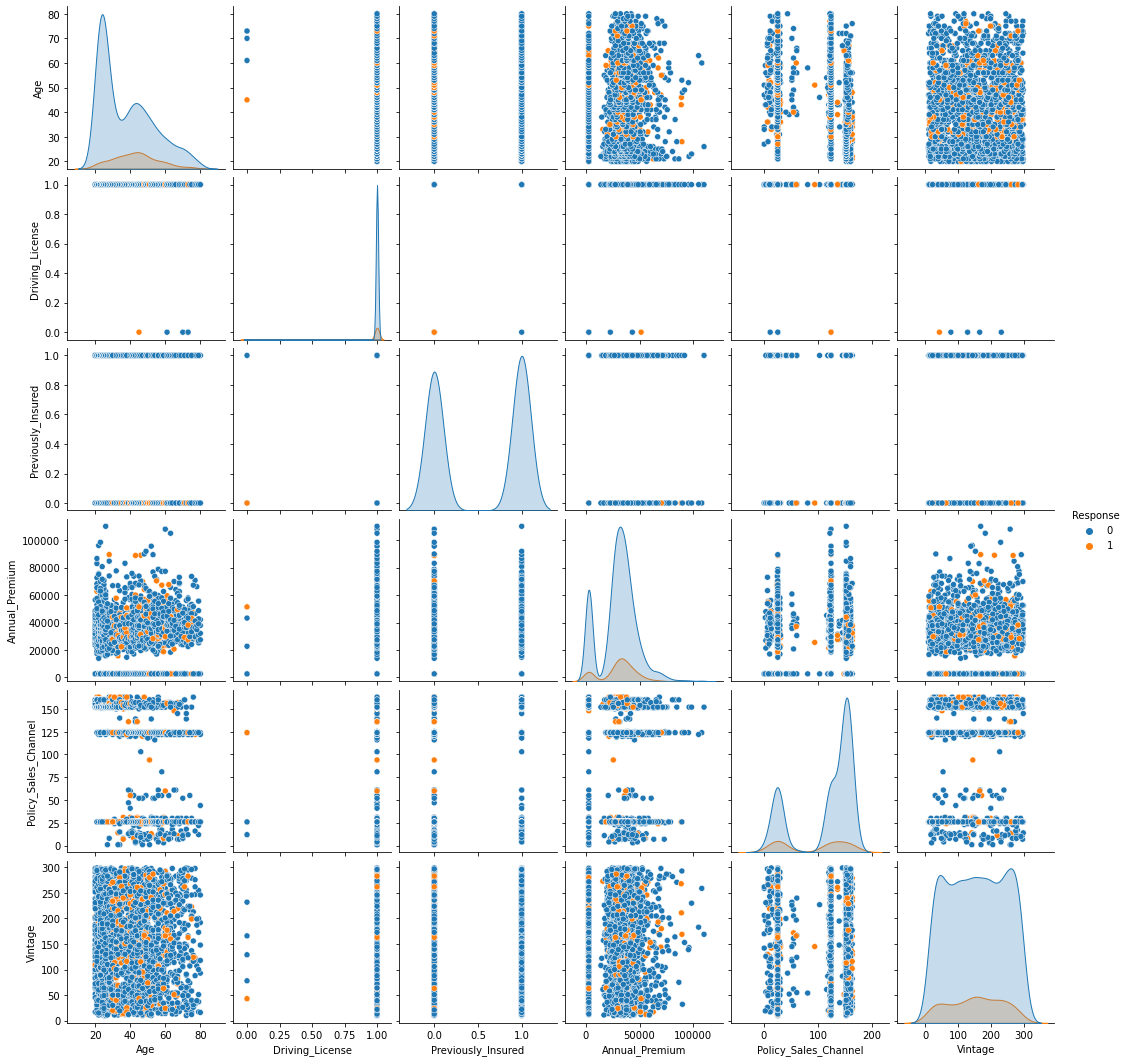

In [51]:
# This one takes a lot of time as well i should definitely sample the data.

sns.pairplot(pd.concat([x_train, y_train], axis=1), hue="Response")

In [52]:
def plot_histogram(df, feat_name, bins=20, figsize=(20,10)):  
    hists = df.select(feat_name).rdd.flatMap(lambda row: row).histogram(bins)

    data = {
       'bins': hists[0][:-1],
       'freq': hists[1]
      }
    plt.figure(figsize=figsize)
    plt.bar(data['bins'], data['freq'], width=2000)
    plt.title('Histogram of \'{}\''.format(feat_name))
    plt.show();

In [53]:
train_data = spark.createDataFrame(data=pd.concat([x_train, y_train], axis=1))
test_data = spark.createDataFrame(data=pd.concat([x_test, y_test], axis=1))

In [54]:
train_data.cache()
test_data.cache()

DataFrame[Gender: string, Age: bigint, Driving_License: bigint, Previously_Insured: bigint, Vehicle_Age: string, Vehicle_Damage: string, Annual_Premium: double, Policy_Sales_Channel: double, Vintage: bigint, Response: bigint]

***

# Modelling:

## Data preparation:

In [55]:
features_columns = ["Gender", "Age", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage",
  "Annual_Premium", "Policy_Sales_Channel", "Vintage",]

In [56]:
train_data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Driving_License: long (nullable = true)
 |-- Previously_Insured: long (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: long (nullable = true)
 |-- Response: long (nullable = true)



In [57]:
featuresCols = train_data.columns 
featuresCols.remove("Response")

In [58]:
categoricalCols = ["Gender", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage"]
numericCols = ["Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]

indexOutputCols = [f + "_Index" for f in categoricalCols]
oheOutputCols = [f + "_OHE" for f in categoricalCols]

stringIndexer = StringIndexer(inputCols=categoricalCols, outputCols=indexOutputCols, handleInvalid="skip")
oheEncoder = OneHotEncoder(inputCols=indexOutputCols, outputCols=oheOutputCols)
assembler = VectorAssembler(inputCols=numericCols, outputCol= "numfeatures")
scaler = StandardScaler(inputCol="numfeatures", outputCol="scaledFeatures")

vectorAssembler = VectorAssembler(inputCols=oheOutputCols+["scaledFeatures"], outputCol="features")

In [59]:
stages = [stringIndexer, oheEncoder, assembler, scaler, vectorAssembler]

In [60]:
# Thr order of features.

features_names = ["Gender", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage", "Age",
  "Annual_Premium", "Policy_Sales_Channel", "Vintage"]

***

## Logistic regression

In [61]:
lr = LogisticRegression(featuresCol="features", labelCol="Response")

In [62]:
evaluator=BinaryClassificationEvaluator(labelCol="Response", rawPredictionCol='prediction', metricName='areaUnderROC')

In [63]:
paramGrid=ParamGridBuilder() \
                .addGrid(lr.regParam, (0.01, 0.1))\
                .addGrid(lr.maxIter, (5, 10))\
                .addGrid(lr.tol, (1e-4, 1e-5))\
                .addGrid(lr.elasticNetParam, (0.25,0.75))\
                .build()

In [64]:
cv_lr = CrossValidator(estimator=lr,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [65]:
pipeline_model, predDF, y_test, y_pred_test, y_pred_test_proba = Pipeline_model(stages, cv_lr, train_data, test_data)

              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1009
           1       0.00      0.00      0.00       141

    accuracy                           0.88      1150
   macro avg       0.44      0.50      0.47      1150
weighted avg       0.77      0.88      0.82      1150



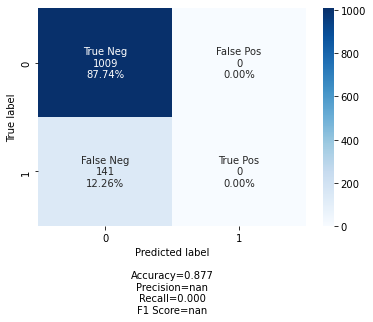

In [66]:
cm = confusion_matrix(y_test, y_pred_test)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['0', '1']
make_confusion_matrix(cm, group_names=labels, categories=categories, cmap='Blues')

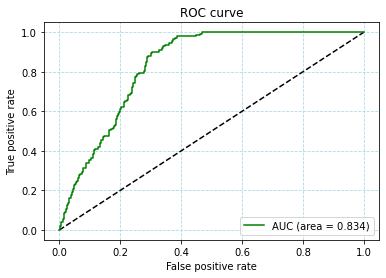

In [67]:
auc_plot(y_test, y_pred_test_proba)

In [68]:
cv_model = pipeline_model.stages[-1]
lr_summary = cv_model.bestModel.summary
lr_summary

In [69]:
features_names = ["Gender", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage", "Age",
  "Annual_Premium", "Policy_Sales_Channel", "Vintage"]


features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.coefficients)),
                             columns=["feature", "Coefficient"]).sort_values(by=["Coefficient"], ascending=False)

display(features_imp)

,feature,Coefficient
5,Age,1.595676
2,Previously_Insured,1.584927
1,Driving_License,0.000000
3,Vehicle_Age,0.000000
7,Policy_Sales_Channel,0.000000
6,Annual_Premium,-0.022572
8,Vintage,-0.116913
0,Gender,-0.167290
4,Vehicle_Damage,-0.377734


In [70]:
roc_df = lr_summary.roc.toPandas()

In [71]:
# list(zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics))

In [72]:
Metrics(predDF)

Accuracy: 0.8774
Precision: 0.0
Recall: 0.0
F1 score: 0.0
Specificity: 1.0
Sensitivity: 0.0


In [73]:
print('Accuracy: ', MulticlassClassificationEvaluator(labelCol='Response',metricName='accuracy').evaluate(predDF))
print('Precision: ',MulticlassClassificationEvaluator(labelCol='Response',metricName='weightedPrecision').evaluate(predDF))

Accuracy:  0.8773913043478261
Precision:  0.7698155009451796


In [74]:
# I don't think it is a good idea to use this, it will just slow down the function.

# performanceMetricsDF(metrics, y_train, y_pred_train, y_test, y_pred_test)

***

## Random forest model:

In [75]:
rf = RandomForestClassifier(featuresCol="features", labelCol="Response", seed=SEED)

In [76]:
evaluator=BinaryClassificationEvaluator(labelCol="Response", rawPredictionCol='prediction', metricName='areaUnderROC')

In [77]:
paramGrid=ParamGridBuilder() \
                .addGrid(rf.maxDepth, [5, 10, 20]) \
                .addGrid(rf.numTrees, [20, 40, 60 ]) \
                .build()

#                 .addGrid(rf.maxBins, [20, 32, 50]) \
#                 .addGrid(rf.minInfoGain, [0., 0.01, 0.1]) \
#                 .addGrid(rf.impurity, ["gini", "entropy"]) \
#                 .addGrid(rf.minInstancesPerNode, [1, 5, 10]) \    

In [78]:
# The other way arround is better I guess:

cv_rf = CrossValidator(estimator=rf,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [79]:
pipeline_model, predDF, y_test, y_pred_test, y_pred_test_proba = Pipeline_model(stages, cv_rf, train_data, test_data)

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1009
           1       0.50      0.12      0.19       141

    accuracy                           0.88      1150
   macro avg       0.69      0.55      0.56      1150
weighted avg       0.84      0.88      0.84      1150



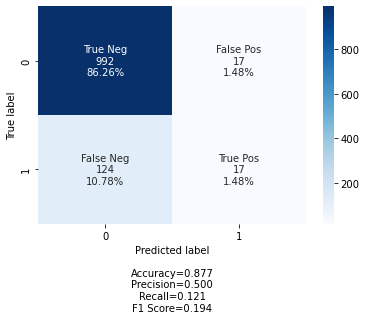

In [80]:
cm = confusion_matrix(y_test, y_pred_test)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['0', '1']
make_confusion_matrix(cm, group_names=labels, categories=categories, cmap='Blues')

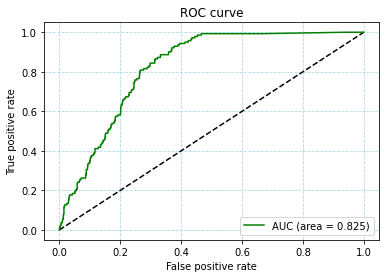

In [81]:
auc_plot(y_test, y_pred_test_proba)

In [82]:
cv_model = pipeline_model.stages[-1]
rf_summary = cv_model.bestModel.summary
rf_summary

In [83]:
features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.featureImportances)),
                             columns=["feature", "importance"])

features_imp.sort_values(by="importance", ascending=False)

,feature,importance
6,Annual_Premium,0.204754
7,Policy_Sales_Channel,0.197034
8,Vintage,0.120706
5,Age,0.109834
2,Previously_Insured,0.063843
0,Gender,0.034476
4,Vehicle_Damage,0.023573
3,Vehicle_Age,0.022502
1,Driving_License,0.002275


In [84]:
# list(zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics))

In [85]:
Metrics(predDF)

Accuracy: 0.8774
Precision: 0.5
Recall: 0.1206
F1 score: 0.1943
Specificity: 0.9832
Sensitivity: 0.1206


***

## Neural Network:

In [95]:
nn = MultilayerPerceptronClassifier(featuresCol="features", labelCol="Response", seed=SEED)

In [96]:
paramGrid=ParamGridBuilder().addGrid(nn.maxIter, [50, 100]).addGrid(nn.layers, [[10, 5, 2]]).build()

In [97]:
cv_nn = CrossValidator(estimator=nn,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [98]:
pipeline_model, predDF, y_test, y_pred_test, y_pred_test_proba = Pipeline_model(stages, cv_nn, train_data, test_data)

              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1009
           1       0.00      0.00      0.00       141

    accuracy                           0.88      1150
   macro avg       0.44      0.50      0.47      1150
weighted avg       0.77      0.88      0.82      1150



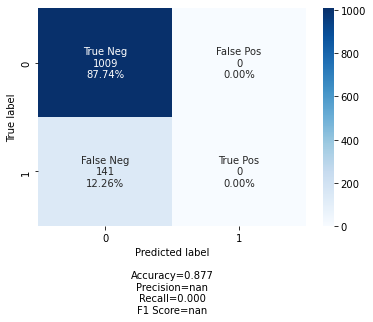

In [99]:
cm = confusion_matrix(y_test, y_pred_test)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['0', '1']
make_confusion_matrix(cm, group_names=labels, categories=categories, cmap='Blues')

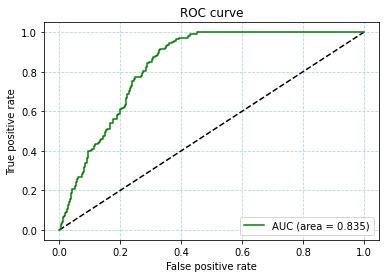

In [100]:
auc_plot(y_test, y_pred_test_proba)

In [101]:
cv_model = pipeline_model.stages[-1]
cv_model.bestModel

MultilayerPerceptronClassificationModel: uid=MultilayerPerceptronClassifier_82988346d18f, numLayers=3, numClasses=2, numFeatures=10

In [102]:
Metrics(predDF)

Accuracy: 0.8774
Precision: 0.0
Recall: 0.0
F1 score: 0.0
Specificity: 1.0
Sensitivity: 0.0


***

## Gradient Boosting:

In [86]:
gb = GBTClassifier(featuresCol="features", labelCol="Response", seed=SEED)

In [87]:
paramGrid=ParamGridBuilder().addGrid(gb.maxDepth, [5, 8, 10]).addGrid(gb.minInstancesPerNode, [5, 10]).build()

## this takes too much time, i need to tweak it to get better results.
#.addGrid(gb.maxBins, [20, 32, 50]) \
                #.addGrid(gb.maxIter, [10, 20, 30]) \

In [88]:
# The other way arround is better I guess:

cv_gb = CrossValidator(estimator=gb,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [89]:
pipeline_model, predDF, y_test, y_pred_test, y_pred_test_proba = Pipeline_model(stages, cv_gb, train_data, test_data)

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1009
           1       0.42      0.16      0.23       141

    accuracy                           0.87      1150
   macro avg       0.66      0.56      0.58      1150
weighted avg       0.83      0.87      0.84      1150



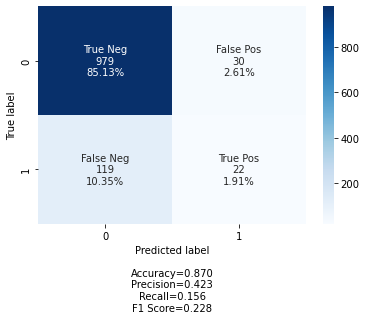

In [90]:
cm = confusion_matrix(y_test, y_pred_test)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['0', '1']
make_confusion_matrix(cm, group_names=labels, categories=categories, cmap='Blues')

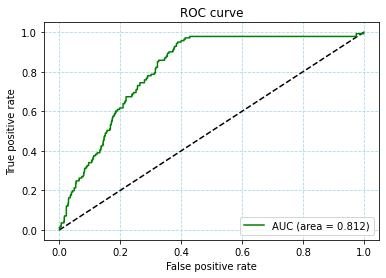

In [91]:
auc_plot(y_test, y_pred_test_proba)

In [92]:
cv_model = pipeline_model.stages[-1]
cv_model.bestModel

GBTClassificationModel: uid = GBTClassifier_dffdf3ccd096, numTrees=20, numClasses=2, numFeatures=10

In [93]:
features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.featureImportances)),
                             columns=["feature", "importance"])

features_imp.sort_values(by="importance", ascending=False)

,feature,importance
6,Annual_Premium,0.249014
7,Policy_Sales_Channel,0.229432
2,Previously_Insured,0.095313
8,Vintage,0.092919
5,Age,0.075143
0,Gender,0.023414
3,Vehicle_Age,0.020373
4,Vehicle_Damage,0.003855
1,Driving_License,0.000000


In [94]:
Metrics(predDF)

Accuracy: 0.8704
Precision: 0.4231
Recall: 0.156
F1 score: 0.2279
Specificity: 0.9703
Sensitivity: 0.156


***

In [103]:
t2 = time.perf_counter()
print('Time taken to run in minutes:',(t2-t1)/60.0)

Time taken to run in minutes: 12.694403131666666
